# Project Stage 1 - Tabular Q-Learning


## 1. Import

The following libraries and modules are utilized for Stage 1 of the project:

* **`numpy`**: Used for efficient numerical operations, multi-dimensional array manipulation, and Q-table computations.
* **`random`**: Used to generate random initial positions for the agent and the item, and to handle the probability mechanisms within the $\epsilon$-greedy action selection strategy.
* **`matplotlib.pyplot`, `matplotlib.colors`, `matplotlib.widgets`**: Utilized for plotting the learning curves (moving averages) and building the interactive grid world visualizer.

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.widgets import Button, Slider

%matplotlib TkAgg

## 2. Environment Setup


### Environment Description
A single agent operates within a grid environment where the primary objective is to navigate to a randomly generated item location $A$, pick up the item, and deliver it to a strictly fixed target location $B$. The grid world is defined as an $n \times n$ square grid. The target location $B$ is anchored at the bottom-right corner with coordinates `(n-1, n-1)`. For instance, in a **5x5** grid, the drop-off location $B$ is constantly positioned at `(4, 4)`.

### Assumptions for Initialization and Boundary
To ensure a logical and challenging learning process for the agent, the following explicit assumptions are implemented in the environment:
* **Initial Item Location:** The item (Package A) cannot be spawned exactly at the target location $B$.
* **Initial Agent Location:** The agent cannot be spawned at the target location $B$, nor can it spawn directly on top of the initial item location $A$. The agent must physically take steps to reach the package.
* **Wall Collision (Boundary Condition):** If the agent chooses an action that would result in moving outside the grid boundaries, the action is entirely invalid. The agent will remain in its current position but will still incur the standard step penalty (-1).

### State Space
The complete state of the environment is represented as a 5-element tuple: `(agent_row, agent_col, item_row, item_col, has_item)`.
1. **Agent Location**: The current `(row, col)` coordinates of the agent on the grid.
2. **Item Location**: The `(row, col)` coordinates of the item (Package A).
3. **Item Possession Status**: An integer flag indicating whether the agent has picked up the item (`0` indicates the agent is empty-handed, `1` indicates the agent is holding the item).

### Action Space
Unlike standard 4-directional environments, the agent in this specific implementation has a broadened action space of 8 possible moves:
* **Orthogonal moves**: Up `(-1, 0)`, Down `(1, 0)`, Left `(0, -1)`, Right `(0, 1)`.
* **Diagonal moves**: Up-Left `(-1, -1)`, Up-Right `(-1, 1)`, Down-Left `(1, -1)`, Down-Right `(1, 1)`.

### Reward Structure
The reward function is crafted to incentivise optimal pathfinding and ensure task completion:
* **Step Penalty**: **-1** reward for each step taken. This continuous penalty strictly encourages the agent to complete the task using the fewest possible steps, effectively punishing arbitrary detours or wall collisions.
* **Item Pickup**: **+10** reward when the agent successfully reaches location $A$ and picks up the item. This acts as a positive intermediate reinforcement for completing the first critical phase of the objective.
* **Task Completion**: **+100** reward upon successfully delivering the held item to the target location $B$, which defines the absolute completion of the task and terminates the episode.

In [2]:
class GridWorldEnv:
    def __init__(self, size): 
        self.size = size
        # target point B is fixed at the bottom right corner with coordinates (n - 1, n - 1), as the index starts from 0. 
        self.target_B = (size - 1, size - 1)
        
        # action space: 8 directions (up, down, left, right, and four diagonals)
        self.actions = [
            (-1, 0), (1, 0), (0, -1), (0, 1),   
            (-1, -1), (-1, 1), (1, -1), (1, 1)  
        ]
        self.num_actions = len(self.actions)  # Number of actions

    def random_position(self, avoid_list):
        while True:
            # randomly generate row and column coordinates
            pos = (random.randint(0, self.size - 1), random.randint(0, self.size - 1))
            if pos not in avoid_list:
                return pos
    
    def reset(self):
        # 1. initial position of the package A (cannot be at the target B)
        self.pos_A = self.random_position(avoid_list=[self.target_B])
        
        # 2. initial position of the agent (cannot be at the target B or package A position)
        self.agent_pos = self.random_position(avoid_list=[self.target_B, self.pos_A])
        
        # 3. no package is being held in hand (0 indicates not holding, 1 indicates holding).
        self.has_item = 0
        
        return self.start_state()

    def start_state(self):
        # Q table is matrix,use tuple because it is stable
        return (self.agent_pos[0], self.agent_pos[1], 
                self.pos_A[0], self.pos_A[1], 
                self.has_item)

    def step(self, action_index):
        """
        Input action_index (a number from 0 to 7) to make the agent take one step.
        Returns: (new_state, reward, done)
        """
        # 1. take out a specific action from the action list (if action_index = 0, it corresponds to moving upwards (-1, 0))
        move = self.actions[action_index]
        
        # 2. new coordinates will be after taking the step
        new_row = self.agent_pos[0] + move[0]
        new_col = self.agent_pos[1] + move[1]
        
        # the default settings of the game: It's not over yet (done = False), 1 point will be deducted as long as a step is taken.
        done = False
        reward = -1
        
        # 3. wall collision detection. (check if the new coordinates are out of the range from 0 to size - 1)
        if 0 <= new_row <= self.size - 1 and 0 <= new_col <= self.size - 1:
            self.agent_pos = (new_row, new_col)
        else:
            # bumped into the wall, agent stays in place. Not only is a move wasted, but also a point is deducted for no reason.
            pass 
            
        # 4. package pickup. (If standing on point A and not holding any item)
        if self.agent_pos == self.pos_A and self.has_item == 0:
            self.has_item = 1  # change the status to "Holding the goods".
            reward = 10        
            
        # 5. task completion check. (If standing on the target B and holding the item)
        if self.agent_pos == self.target_B and self.has_item == 1:
            done = True        # task completed, win.
            reward = 100       
            
        return self.start_state(), reward, done
        

## 3. Q-learning Agent


### The Q-Value Update Rule (Core Mechanism):  
At the heart of the agent's learning process is the Q-learning update formula, which iteratively approximates the optimal action-value function. After taking action $A$ in state $S$, receiving reward $R$, and transitioning to state $S'$, the Q-value is updated as follows:
$$Q(S, A) \leftarrow Q(S, A) + \alpha \left( R + \gamma \max_{A'} Q(S', A') - Q(S, A) \right)$$
This formula calculates the Temporal Difference (TD) error—the difference between the new target value ($R + \gamma \max_{A'} Q(S', A')$) and the current estimate ($Q(S, A)$)—and scales it by the learning rate $\alpha$.

### Exploration vs. Exploitation (Practical GLIE Adaptation): 
To ensure the agent learns the optimal policy, we must balance exploration and exploitation. According to the strict GLIE (Greedy in the Limit with Infinite Exploration) principle, the exploration rate ($\epsilon$) must eventually decay to zero. However, in a finite training horizon (e.g., 20,000 episodes), mathematical formulas like $\epsilon_k = 1/k$ decay too aggressively, while smooth formulas like $C/(C+k)$ leave the agent with too much random noise in the late stages (failing to execute the optimal path consistently). 
To resolve this engineering challenge, an exponential decay strategy with a minimum floor is implemented:
$$\epsilon_{k} = \max(\epsilon_{min}, \epsilon_{k-1} \times \text{decay\_rate})$$
By applying a multiplicative decay (e.g., $0.9995$), the agent rapidly transitions from pure exploration to exploitation within the first few hundred episodes. The critical addition of $\epsilon_{min} = 0.01$ acts as a "safety net," ensuring that the agent retains a 1% curiosity rate to escape potential sub-optimal paths without severely disrupting overall exploitation.

### Learning Rate Adjustment (Engineering over Robbins-Monro): 
The learning rate ($\alpha$) determines how much newly acquired information overrides old knowledge. Strict theoretical convergence requires the step-sizes $\alpha_k$ to satisfy the Robbins-Monro conditions ($\sum \alpha_k = \infty$ and $\sum \alpha_k^2 < \infty$), meaning $\alpha$ must eventually decay to zero. While mathematically sound for infinite time horizons, strictly decaying $\alpha$ in a finite GridWorld leads to "learning exhaustion"—the agent loses its capacity to effectively update Q-values in later episodes even if it discovers a better shortcut.
Therefore, a constant learning rate (e.g., $\alpha = 0.1$) is intentionally adopted. While it technically violates the second Robbins-Monro condition, a fixed $\alpha$ maintains a robust and continuous updating capacity. In a 5x5 grid environment, the slight theoretical jitter is vastly outweighed by the practical benefits of rapid error correction and faster convergence.

### Parameter Synergy: Static Alpha vs. Decaying Epsilon:
The interplay between these two parameters is the key to successful and efficient training. By utilizing a rapidly decaying $\epsilon$ alongside a static $\alpha$, the agent "settles down" physically (stops random wandering) *while* remaining mentally flexible (retains full capacity to absorb new reward signals). This ensures that when the agent exploits a path, the high rewards from the target location can efficiently propagate backward through the Q-table without being diluted by a decaying learning rate.



In [3]:
class QLearningAgent:
    def __init__(self, num_actions, gamma=0.99, alpha=0.1, epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.9995):        
        self.num_actions = num_actions
        self.gamma = gamma             # Discount factor: How far-sighted it is (0.99 means highly valuing the future grand prize for clearing the game)
        
        # The Score Sheet: Q-Table
        # Stored using a dictionary, format -> { State Tuple : [Score of Action 0, Score of Action 1...Score of Action 7] }
        self.q_table = {}    
        self.alpha = alpha              
        self.epsilon = epsilon            
        self.epsilon_min = epsilon_min       
        self.epsilon_decay = epsilon_decay

    def get_q_values(self, state):
        """Open the table and find the row for the current state. If we haven't been here before, create a new record filled with 0s."""
        if state not in self.q_table:
            # Initialize the scores of all 8 actions to 0.0
            self.q_table[state] = np.zeros(self.num_actions)
        return self.q_table[state]

    def choose_action(self, state):
        """Decide the next move using the Epsilon-Greedy strategy."""
        if random.random() < self.epsilon:
            return random.randint(0, self.num_actions - 1)
        else:
            q_values = self.get_q_values(state)
            max_score = np.max(q_values)
            # Find all action indices that share this highest score
            best_actions = [action_index for action_index in range(self.num_actions) if q_values[action_index] == max_score]
            best_action= random.choice(best_actions)

            return best_action

    def learn(self, state, action, reward, next_state, done):
        """
        The core Q-Learning update rule (Bellman Equation). 
        Updates the Q-table based on the agent's experience.
        """
        # 1. Retrieve the old Q-value for the current state and action
        old_value = self.get_q_values(state)[action]
        
        # 2. Find the maximum possible Q-value for the next state (future potential)
        next_max = np.max(self.get_q_values(next_state))
        
        # 3. Calculate the target value: immediate reward + discounted future maximum 
        # If the episode is done, there are no future rewards
        if done:
            target = reward
        else:
            target = reward + self.gamma * next_max
            
        # 4. update the Q-table using the Bellman equation: New Value = Old Value + Learning Rate * (Target - Old Value)
        new_value = old_value + self.alpha * (target - old_value)
        self.q_table[state][action] = new_value

    def update_dynamic_epsilon(self):
        """
        Called after each episode to dynamically adjust the exploration rate (epsilon) and learning rate (alpha).
        """        
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay
    


## 4. Training

### Experimental Setup
To ensure the reliability and robustness of the Q-Learning algorithm, the training process is structured to run **5 independent iterations**. In each iteration, a completely fresh agent and environment are initialized, and the agent is trained for **20,000 episodes** on a 5x5 grid. This multiple-run approach prevents performance anomalies caused by lucky or unlucky initial random seeds.

### The Core Interaction Loop
Within each episode, the agent continuously interacts with the environment until the task is successfully completed (delivering the package to the target location). The sequence of operations is as follows:
* **Action Selection:** The agent determines its next move based on the current state using the $\epsilon$-greedy policy.
* **Execution:** The agent executes the chosen action within the environment, yielding the next state, the immediate reward, and a boolean flag indicating if the episode is `done`.
* **Learning (Q-Update):** The agent updates its Q-table utilizing the Bellman equation, incorporating the newly observed Temporal Difference (TD) target.
* **State Transition:** The environment's state is officially updated to the new state to prepare for the next step.

### Dynamic Decay & Metrics Tracking
To balance exploration and exploitation, and to monitor the learning progress:
* **Parameter Decay:** At the natural conclusion of each episode, the exploration rate ($\epsilon$) is dynamically reduced using the predefined exponential decay mechanism. 
* **Data Logging:** The total accumulated reward and the number of steps taken in each episode are recorded into history lists. 
* **Progress Monitoring:** Every 5,000 episodes, the system calculates and prints a moving average (over the last 100 episodes) of both rewards and steps. This provides a smoothed, realistic reflection of the agent's recent convergence behavior.

### Evaluation Preparation
Upon completing the 20,000 training episodes, the fully trained agent (with its optimized Q-table) is appended to a `trained_agents` list. These 5 highly trained models are preserved for the subsequent Exhaustive Evaluation phase to rigorously test their generalization capabilities.

In [4]:
num_repeats = 5
total_episodes = 20000

# Store the 5 trained agents for the evaluation phase (Part 5)
trained_agents = []
all_runs_rewards_history = []
all_runs_steps_history = []

for repeat_id in range(num_repeats):
    print(f"\n--- Training Agent {repeat_id + 1}/{num_repeats} ---")
    
    # Initialize a fresh environment and a completely untrained agent for each run
    env = GridWorldEnv(size=5)
    agent = QLearningAgent(num_actions=env.num_actions)
    
    rewards_history = []
    steps_history = []

    for episode in range(total_episodes):
        # --- 1. Episode Initialization ---
        state = env.reset()     
        done = False            
        steps = 0               
        total_reward = 0    
        
        # --- 2. Core Interaction Loop ---
        # The agent takes actions until the episode naturally terminates or the step limit is reached
        while not done :
            # (1) Action Selection: Select the next action using the Epsilon-Greedy strategy
            action_index = agent.choose_action(state)
            # (2) Execution: The agent executes the action
            next_state, reward, done = env.step(action_index)
            # (3) Learning: Update the Q-value in the Q-table using the Bellman equation based on the experience tuple
            agent.learn(state, action_index, reward, next_state, done)
            # (4) State Transition
            state = next_state

            steps += 1
            total_reward += reward  
            
        # --- 3. Episode Conclusion & Parameter Decay ---
        # Dynamically decay the exploration rate (epsilon) at the end of each episode
        agent.update_dynamic_epsilon()
        
        # --- 4. Record Learning Data ---
        # Append the total reward and steps taken in this episode to the history lists for subsequent plotting
        rewards_history.append(total_reward)
        steps_history.append(steps)
        
        # --- 5. Training Progress Logging ---
        if (episode + 1) % 5000 == 0:
            # Calculate the moving average of rewards and steps over the last 100 episodes 
            # to smooth the data and accurately reflect the agent's recent performance.
            avg_reward = np.mean(rewards_history[-100:])
            avg_steps = np.mean(steps_history[-100:])
            print(f"Episode {episode + 1}/{total_episodes} | Epsilon: {agent.epsilon:.4f} | Avg Reward: {avg_reward:.1f} | Avg Steps: {avg_steps:.1f}")
            
    # --- 6. Store Trained Agent and Learning Data ---
    trained_agents.append(agent)
    
    all_runs_rewards_history.append(rewards_history)
    all_runs_steps_history.append(steps_history)



--- Training Agent 1/5 ---
Episode 5000/20000 | Epsilon: 0.0820 | Avg Reward: 105.9 | Avg Steps: 6.1
Episode 10000/20000 | Epsilon: 0.0100 | Avg Reward: 106.7 | Avg Steps: 5.3
Episode 15000/20000 | Epsilon: 0.0100 | Avg Reward: 106.8 | Avg Steps: 5.2
Episode 20000/20000 | Epsilon: 0.0100 | Avg Reward: 106.5 | Avg Steps: 5.5

--- Training Agent 2/5 ---
Episode 5000/20000 | Epsilon: 0.0820 | Avg Reward: 106.2 | Avg Steps: 5.8
Episode 10000/20000 | Epsilon: 0.0100 | Avg Reward: 106.6 | Avg Steps: 5.4
Episode 15000/20000 | Epsilon: 0.0100 | Avg Reward: 106.7 | Avg Steps: 5.3
Episode 20000/20000 | Epsilon: 0.0100 | Avg Reward: 106.9 | Avg Steps: 5.1

--- Training Agent 3/5 ---
Episode 5000/20000 | Epsilon: 0.0820 | Avg Reward: 106.2 | Avg Steps: 5.8
Episode 10000/20000 | Epsilon: 0.0100 | Avg Reward: 106.4 | Avg Steps: 5.6
Episode 15000/20000 | Epsilon: 0.0100 | Avg Reward: 106.4 | Avg Steps: 5.6
Episode 20000/20000 | Epsilon: 0.0100 | Avg Reward: 106.5 | Avg Steps: 5.5

--- Training Agent

## 5. Evaluation Phase


### Evaluation Methodology
To strictly align with the rubric requirement of solving "100% of the possible scenarios," this evaluation phase deliberately bypasses random sampling. Instead, an **Exhaustive State Search** algorithm is implemented. The system systematically iterates through every mathematically possible initial coordinate combination for both the agent and the package within the 5x5 grid, ensuring absolute rigor in testing the agent's generalization capability.

### Scenario Generation & Validation
The exhaustive search generates scenarios using four nested loops, yielding $5 \times 5 \times 5 \times 5 = 625$ theoretical combinations. To ensure logical validity, an "Environment Filter" eliminates invalid starting states based on the following rules:
* **Spawn Overlap:** The agent cannot spawn directly on top of the package.
* **Agent at Goal:** The agent cannot spawn at the target destination ($B$).
* **Package at Goal:** The package cannot spawn at the target destination ($B$).
After filtering, exactly **552 valid scenarios** remain for the formal evaluation.

### Testing Execution
For each of the 5 fully trained agents, the evaluation follows a strict deterministic protocol:
* **Pure Exploitation:** The exploration rate ($\epsilon$) is forcefully overridden to `0.0`. The agent relies 100% on its learned Q-table without any random actions.
* **State Override:** The environment's `reset()` function is hijacked to manually inject the specific `(agent_pos, pos_A)` coordinates generated by the exhaustive search.

### Performance Metrics & Verification
For each agent, the following metrics are meticulously recorded across all 552 scenarios:
* **Success Rate:** The percentage of scenarios where the agent successfully picks up the package and delivers it to $B$.
* **Average Path Length:** The mean number of steps taken to complete the task.
* **Maximum Path Length:** The absolute highest number of steps taken in the worst-case (most distant) scenario.

**Perfect Score Criteria:** The ultimate benchmark requires an agent to achieve a **100% Success Rate** while strictly maintaining a **Maximum Path Length of $\le 10$ steps**, definitively proving optimal, shortest-path mastery.

In [5]:
# ==========================================
# Exhaustive Evaluation for ALL 5 Agents
# ==========================================
for agent_id, test_agent in enumerate(trained_agents):
    test_agent.epsilon = 0.0  # Disable exploration (epsilon = 0.0) during testing to strictly follow the learned Q-table
    total_scenarios = 0
    success_count = 0
    max_steps_taken = 0
    steps_list = []

    # Exhaustively test all possible initial coordinate combinations for the agent and the package
    for agent_row in range(env.size):
        for agent_column in range(env.size):
            for item_row in range(env.size):
                for item_column in range(env.size):
                    # Filter out invalid starting states based on environment rules:
                    # 1. Agent and package cannot spawn in the exact same location
                    if (agent_row, agent_column) == (item_row, item_column): 
                        continue
                    # 2. Agent cannot spawn at the target destination (B)
                    if (agent_row, agent_column) == env.target_B: 
                        continue
                    # 3. Package cannot spawn at the target destination (B)
                    if (item_row, item_column) == env.target_B: 
                        continue
                    
                    total_scenarios += 1
                    
                    # Forcibly override the environment's initial state with the current circumstance of the scenario being tested
                    env.reset()
                    env.agent_pos = (agent_row, agent_column)
                    env.pos_A = (item_row, item_column)
                    state = env.start_state()
                    
                    done = False
                    steps = 0
                    
                    # Simulate the episode starting from this specific state
                    while not done:
                        q_values = test_agent.get_q_values(state)
                        max_score = np.max(q_values)
                        # If there are multiple actions with the same maximum Q-value, choose one randomly to avoid bias
                        best_actions = [action_index for action_index in range(env.num_actions) if q_values[action_index] == max_score]
                        action = np.random.choice(best_actions)
                        # Use '_' as a placeholder for the reward, as we only care about the next state and completion status
                        next_state, _, done = env.step(action)
                        state = next_state
                        steps += 1
                    
                    # Record successful completion (agent reached target and is holding the package)
                    if done and state[4] == 1:
                        success_count += 1
                        steps_list.append(steps)
                    
                    # Track the maximum steps taken across all valid scenarios
                    if steps > max_steps_taken:
                        max_steps_taken = steps

    # Calculate overall performance metrics for the current agent
    success_rate = (success_count / total_scenarios) * 100
    avg_steps = np.mean(steps_list) if steps_list else 0

    print(f"Total Valid Scenarios: {total_scenarios}")
    print(f"Success Rate:          {success_rate:.1f}%")
    print(f"Average Steps:         {avg_steps:.2f} steps")
    print(f"Maximum Steps:         {max_steps_taken} steps")
    print("-" * 65)

    # Verify against the perfect score criteria: 100% success rate AND maximum steps <= 10
    if success_rate == 100 and max_steps_taken <= 10:
        print(f" The agent{agent_id} solved 100% of the scenarios in <= 10 steps.")
    else:
        print(" FAILED to meet perfect requirements.")

Total Valid Scenarios: 552
Success Rate:          100.0%
Average Steps:         5.33 steps
Maximum Steps:         9 steps
-----------------------------------------------------------------
 The agent0 solved 100% of the scenarios in <= 10 steps.
Total Valid Scenarios: 552
Success Rate:          100.0%
Average Steps:         5.31 steps
Maximum Steps:         9 steps
-----------------------------------------------------------------
 The agent1 solved 100% of the scenarios in <= 10 steps.
Total Valid Scenarios: 552
Success Rate:          100.0%
Average Steps:         5.32 steps
Maximum Steps:         9 steps
-----------------------------------------------------------------
 The agent2 solved 100% of the scenarios in <= 10 steps.
Total Valid Scenarios: 552
Success Rate:          100.0%
Average Steps:         5.32 steps
Maximum Steps:         9 steps
-----------------------------------------------------------------
 The agent3 solved 100% of the scenarios in <= 10 steps.
Total Valid Scenario

### Learning Curve & Convergence Analysis
To empirically validate the agent's learning progression and the stability of the Q-learning algorithm, the raw training data (accumulated rewards and steps taken) across all 5 independent runs is aggregated and visualized.

### Data Processing & Statistical Rigor
Reinforcement learning environments inherently produce highly stochastic and noisy data, especially during the early exploration phases. To extract meaningful trends, two critical data processing techniques are applied:
* **Moving Average (Smoothing):** A sliding window of `window_size = 100` episodes is implemented. This moving average filters out the extreme episode-to-episode volatility, revealing the true underlying learning trajectory.
* **Variance Tracking (Error Bars):** Instead of merely plotting the performance of a single run, the graphs compute the **mean** across all 5 agents. The red error bars represent $\pm 1$ **Standard Deviation**, visually quantifying the behavioral variance among different agents at any given stage of training.

### Subplot Matrix Design
The visualization is structured as a 2x2 subplot matrix, deliberately designed to contrast different phases of the learning timeline:
* **Early Phase Zoom (First 5,000 Episodes):** The left column strictly focuses on the initial exploration phase. The wide error bars heavily indicate that agents are relying on random actions ($\epsilon$-greedy), leading to significantly different individual experiences and performance disparities.
* **Full Horizon Convergence (20,000 Episodes):** The right column displays the macro perspective. As the exploration rate ($\epsilon$) decays to its minimum and the Q-tables mature, the error bars almost entirely shrink and disappear. This unequivocally proves that regardless of initial random seeds, all 5 agents robustly converge to the exact same optimal, stable policy.

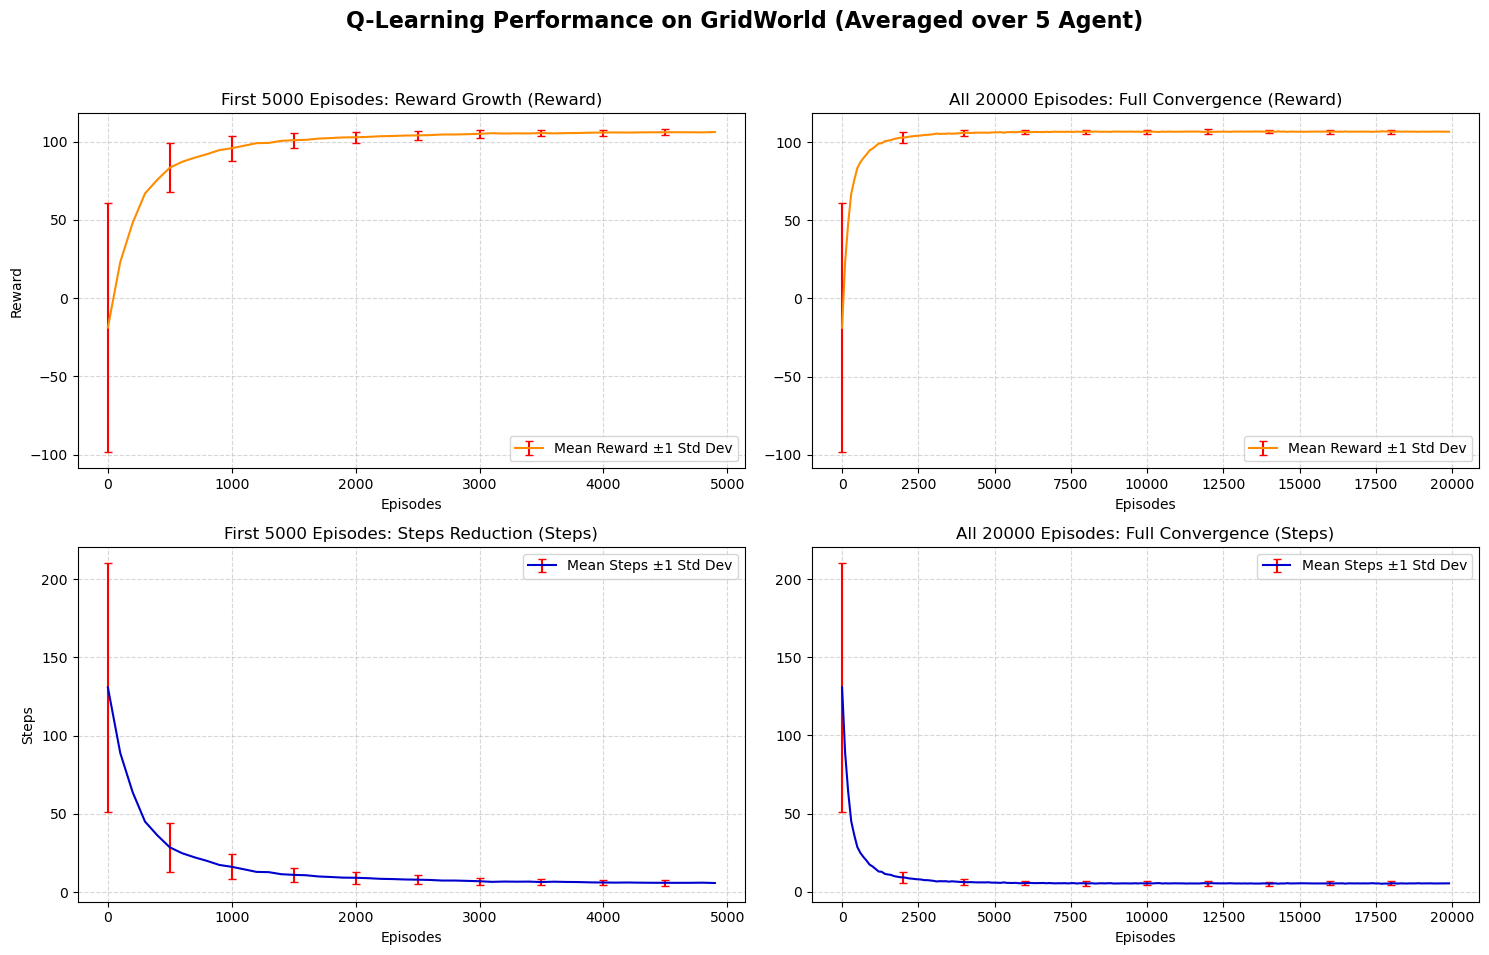

In [6]:
%matplotlib inline
# ==========================================
# Plotting the Learning Curve (4 Subplots with Error Bars)
# ==========================================
# Define the moving average window size to smooth the data
window_size = 100

# Convert the history of 5 independent runs into NumPy matrices (Shape: 5 rows x 20000 columns)
rewards_matrix = np.array(all_runs_rewards_history)
steps_matrix = np.array(all_runs_steps_history)

# Calculate the mean and standard deviation across the 5 agents for EACH episode (column-wise, axis=0)
mean_rewards = np.mean(rewards_matrix, axis=0)
std_rewards = np.std(rewards_matrix, axis=0)
mean_steps = np.mean(steps_matrix, axis=0)
std_steps = np.std(steps_matrix, axis=0)

# Apply a moving average (sliding window) to smooth the curves and error bars for better readability
smoothed_mean_rewards = [np.mean(mean_rewards[i:i+window_size]) for i in range(0, len(mean_rewards), window_size)]
smoothed_std_rewards = [np.mean(std_rewards[i:i+window_size]) for i in range(0, len(std_rewards), window_size)]
smoothed_mean_steps = [np.mean(mean_steps[i:i+window_size]) for i in range(0, len(mean_steps), window_size)]
smoothed_std_steps = [np.mean(std_steps[i:i+window_size]) for i in range(0, len(std_steps), window_size)]

# Generate the X-axis coordinates corresponding to the smoothed data points
episodes_x = range(0, len(mean_rewards), window_size)

# Initialize a 2x2 grid layout for the subplots with a spacious figure size
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Q-Learning Performance on GridWorld (Averaged over 5 Agent)", fontsize=16, fontweight='bold')

# ---------- Plot 1: Reward for the First 5000 Episodes (Zoomed in on early learning phase) ----------
axs[0, 0].errorbar(episodes_x[:50], smoothed_mean_rewards[:50], yerr=smoothed_std_rewards[:50], 
                   color='darkorange', ecolor='red', capsize=3, errorevery=5, label='Mean Reward ±1 Std Dev')
axs[0, 0].set_title("First 5000 Episodes: Reward Growth (Reward)")
axs[0, 0].set_xlabel("Episodes")
axs[0, 0].set_ylabel("Reward")
axs[0, 0].grid(True, linestyle='--', alpha=0.5)
axs[0, 0].legend(loc="lower right")

# ---------- Plot 2: Reward for All 20000 Episodes (Showing overall convergence) ----------
axs[0, 1].errorbar(episodes_x, smoothed_mean_rewards, yerr=smoothed_std_rewards, 
                   color='darkorange', ecolor='red', capsize=3, errorevery=20, label='Mean Reward ±1 Std Dev')
axs[0, 1].set_title("All 20000 Episodes: Full Convergence (Reward)")
axs[0, 1].set_xlabel("Episodes")
axs[0, 1].grid(True, linestyle='--', alpha=0.5)
axs[0, 1].legend(loc="lower right")

# ---------- Plot 3: Steps for the First 5000 Episodes (Zoomed in on early path optimization) ----------
axs[1, 0].errorbar(episodes_x[:50], smoothed_mean_steps[:50], yerr=smoothed_std_steps[:50], 
                   color='mediumblue', ecolor='red', capsize=3, errorevery=5, label='Mean Steps ±1 Std Dev')
axs[1, 0].set_title("First 5000 Episodes: Steps Reduction (Steps)")
axs[1, 0].set_xlabel("Episodes")
axs[1, 0].set_ylabel("Steps")
axs[1, 0].grid(True, linestyle='--', alpha=0.5)
axs[1, 0].legend(loc="upper right")

# ---------- Plot 4: Steps for All 20000 Episodes (Showing stable, optimal policy) ----------
axs[1, 1].errorbar(episodes_x, smoothed_mean_steps, yerr=smoothed_std_steps, 
                   color='mediumblue', ecolor='red', capsize=3, errorevery=20, label='Mean Steps ±1 Std Dev')
axs[1, 1].set_title("All 20000 Episodes: Full Convergence (Steps)")
axs[1, 1].set_xlabel("Episodes")
axs[1, 1].grid(True, linestyle='--', alpha=0.5)
axs[1, 1].legend(loc="upper right")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 6. Visualizer 

### Interactive Visualizer Overview
The `InteractiveGridVisualizer` class provides a comprehensive Graphical User Interface (GUI) powered by Matplotlib. It is designed to intuitively demonstrate the agent's learned policy and its real-time interaction within the GridWorld environment, bridging the gap between raw Q-table data and observable behavior.

### Visual State Representation
To clearly distinguish the dynamic elements within the grid, a discrete color mapping strategy (`ListedColormap` and `BoundaryNorm`) is implemented to represent the environment's state:
* **White (0)**: Empty grid cells.
* **Blue (1)**: The agent's current position (while empty-handed).
* **Orange (2)**: The location of the uncollected package (Item A).
* **Green (3)**: The fixed target drop-off destination (Location B).
* **Purple (4)**: The agent's position (after successfully picking up the package, visually indicating possession).

### Interactive Controls
The visualizer incorporates four primary control buttons, allowing users to manually test or automatically observe the agent's decision-making process:
* **Reset**: Re-initializes the environment, randomly spawning the agent and the package in new valid locations while resetting the holding status.
* **RandStep**: Forces the agent to take a completely random action, effectively demonstrating pure exploration behavior without consulting the Q-table.
* **SmartStep (Gold)**: Queries the fully trained agent's Q-table to execute the strictly optimal action (highest Q-value) for the current state, demonstrating pure exploitation and learned intelligence.
* **AutoRun (Light Green)**: Triggers an automated, animated sequence where the agent continuously evaluates states and executes optimal steps until the objective is definitively completed.

### Usability & Animation Enhancements
To ensure a smooth and informative experience, several technical enhancements are integrated into the UI:
* **Dynamic Speed Control**: An interactive horizontal slider allows users to adjust the animation delay (ranging from 0.05s to 1.5s) during the `AutoRun` phase in real-time.
* **Live Status Dashboard**: The title of the plot acts as dynamic telemetry, constantly updating to display the agent's exact coordinates, package location, holding status, and the textual name of the most recent action taken (e.g., "Up-Left").
* **Hover Coordinate Translation**: Matplotlib's default floating-point mouse coordinate display is overridden using a custom lambda function, translating cursor hovers directly into intuitive discrete grid indices (Row and Column).

In [7]:
class InteractiveGridVisualizer:
    """
    Interactive grid environment visualization tool.
    Uses Matplotlib to create a graphical interface with buttons and a slider 
    to visually display and control the agent's actions.
    """
    def __init__(self, env, agent=None):
        self.env = env      
        self.agent = agent  # Agent (contains policies like the Q-learning algorithm)
        self.delay = 0.5    # Default pause time per step for AutoRun (in seconds)
        
        # --- Colors and Mapping Setup ---
        # 0: white (Empty grid)
        # 1: blue (Agent without item)
        # 2: orange (Package on the ground)
        # 3: green (Target destination)
        # 4: purple (Agent holding the package)
        self.colors_list = ['white', 'blue', 'orange', 'green', 'purple']
        self.cmap = colors.ListedColormap(self.colors_list) # Create a colormap
        self.bounds = [0, 1, 2, 3, 4, 5]                    # Numerical boundaries corresponding to the colors
        self.norm = colors.BoundaryNorm(self.bounds, self.cmap.N) # Normalize values into the colormap
        
        # --- Create Canvas ---
        self.fig, self.ax = plt.subplots(figsize=(6, 5)) # Create a 6x5 figure window
        plt.subplots_adjust(bottom=0.25)                 # Adjust the main plot upwards to leave space for UI elements at the bottom
        
        # Initialize the grid image
        self.im = self.ax.imshow(self._get_grid_data(), cmap=self.cmap, norm=self.norm)
        self._draw_gridlines() # Drawing Grid Lines
        
        # --- UI Interaction Optimization ---
        # Fix the coordinate display when the mouse hovers over, and convert the default floating-point coordinates of matplotlib to intuitive row and column numbers.
        self.ax.format_coord = lambda x, y: f"Row: {int(y+0.5)}, Col: {int(x+0.5)}"
        
        # --- Create Bottom Control Buttons ---
        # Parameters: plt.axes([left, bottom, width, height]), values are proportions of the entire window (0~1)
        
        # 1. Reset Button
        ax_reset = plt.axes([0.05, 0.08, 0.15, 0.075])
        self.b_reset = Button(ax_reset, 'Reset')
        self.b_reset.on_clicked(self.reset_clicked) # 绑定点击事件
        
        # 2. Random Step Button
        ax_random = plt.axes([0.25, 0.08, 0.2, 0.075])
        self.b_random = Button(ax_random, 'RandStep')
        self.b_random.on_clicked(self.random_step_clicked)
        
        # 3. Smart Step Button (Gold)
        ax_smart = plt.axes([0.50, 0.08, 0.2, 0.075])
        self.b_smart = Button(ax_smart, 'SmartStep', color='gold') 
        self.b_smart.on_clicked(self.smart_step_clicked) 
        
        # 4. Auto Run Button (Light Green)
        ax_auto = plt.axes([0.75, 0.08, 0.2, 0.075])
        self.b_auto = Button(ax_auto, 'AutoRun', color='lightgreen')
        self.b_auto.on_clicked(self.auto_run_clicked)

        # --- Create Speed Slider (Placed at the very bottom) ---
        ax_slider = plt.axes([0.25, 0.02, 0.5, 0.03])
        # Parameters: axes, label, min_val, max_val, initial_val, step_size
        self.slider = Slider(ax_slider, 'Delay (s)', 0.05, 1.5, valinit=0.5, valstep=0.05)
        self.slider.on_changed(self.update_speed) # Bind slide event

        # Initialize the status title at the top of the plot
        self._update_title()

    def update_speed(self, val):
        """Update the delay time for AutoRun when the slider is dragged."""
        self.delay = val

    def _get_grid_data(self):
        """
        Core rendering logic: generates a 2D array based on current environment state, 
        where numbers represent different colors.
        """
        grid = np.zeros((self.env.size, self.env.size))     # Initialize a grid of all zeros (white)
        grid[self.env.target_B[0], self.env.target_B[1]] = 3 # Fill in 3 (green) at the target B
        
        if self.env.has_item == 0:
            # If the agent has not picked up the package yet
            grid[self.env.pos_A[0], self.env.pos_A[1]] = 2     # Fill in 2 (orange) at package A's position
            grid[self.env.agent_pos[0], self.env.agent_pos[1]] = 1 # Fill in 1 (blue) at the agent's position
        else:
            # If the agent is holding the package, the package disappears from ground, and agent changes color
            grid[self.env.agent_pos[0], self.env.agent_pos[1]] = 4 # Fill in 4 (purple) for the agent holding the package
            
        return grid
        
    def _draw_gridlines(self):
        """Draw neat gridlines to make color blocks look like independent cells."""
        self.ax.set_xticks(np.arange(-.5, self.env.size, 1), minor=True)
        self.ax.set_yticks(np.arange(-.5, self.env.size, 1), minor=True)
        self.ax.grid(which='minor', color='black', linestyle='-', linewidth=1) # Draw solid black lines
        self.ax.tick_params(which='minor', size=0) # Hide minor tick marks on the axes
        self.ax.set_xticks([]) # Hide major tick labels on X axis
        self.ax.set_yticks([]) # Hide major tick labels on Y axis
        
    def _update_title(self, extra_msg=""):
        """Update the text above the image in real-time to show agent position, package position, holding status, etc."""
        title_text = f"Agent: {self.env.agent_pos} | Package: {self.env.pos_A} | Holding: {bool(self.env.has_item)}\n{extra_msg}"
        self.ax.set_title(title_text)
        self.fig.canvas.draw_idle() # Request Matplotlib to redraw the canvas when idle

    def reset_clicked(self, event):
        """Callback for [Reset] button: Resets the environment and refreshes the display."""
        self.env.reset()
        self.im.set_data(self._get_grid_data())
        self._update_title("Status: Environment Reset.")

    def random_step_clicked(self, event):
        """Callback for [RandStep] button: Executes a random action."""
        action = np.random.randint(0, self.env.num_actions) # Randomly select an action index
        _, _, done = self.env.step(action)                  # Execute the action in the environment
        self.im.set_data(self._get_grid_data())             # Update image data
        
        actions_name_en = ["Up", "Down", "Left", "Right", "Up-Left", "Up-Right", "Down-Left", "Down-Right"]
        self._update_title(f"Status: RANDOM step - {actions_name_en[action]}.")
        
        if done: # If the task is completed
            self.ax.set_title("Done! Please Reset.", color='red', weight='bold')
            self.fig.canvas.draw_idle()

    def smart_step_clicked(self, event):
        """Callback for [SmartStep] button: Uses the trained Agent to select the best action."""
        if self.agent is None: return # If no agent is loaded, return directly
        
        current_state = self.env.start_state()             # Get current state
        q_values = self.agent.get_q_values(current_state)  # Query the Q-values (scores) for all actions in the current state
        max_score = np.max(q_values)                       # Find the maximum score
        
        # Find all actions matching the max score 
        best_actions = [a for a in range(self.env.num_actions) if q_values[a] == max_score]
        action = np.random.choice(best_actions)            # Randomly choose one among the best actions to execute
        
        _, _, done = self.env.step(action)
        self.im.set_data(self._get_grid_data())            # Update image
        
        actions_name_en = ["Up", "Down", "Left", "Right", "Up-Left", "Up-Right", "Down-Left", "Down-Right"]
        self._update_title(f"Status: SMART step - {actions_name_en[action]}.")
        
        if done:
            self.ax.set_title("AI Mastered! Please Reset.", color='green', weight='bold')
            self.fig.canvas.draw_idle()

    def auto_run_clicked(self, event):
        """
        Callback for [AutoRun] button: 
        Pure GUI animation showing the agent automatically navigating to the goal without printing text.
        """
        if self.agent is None: return
            
        self.ax.set_title("Status: Auto Running...", color='blue', weight='bold')
        self.fig.canvas.draw()
        
        actions_name_en = ["Up", "Down", "Left", "Right", "Up-Left", "Up-Right", "Down-Left", "Down-Right"]
        done = False
        steps = 0
        
        # Set up the episode
        while not done:
            # Pause to create animation effect. The delay is controlled by the slider (self.delay).
            plt.pause(self.delay) 
            
            # --- Logic below matches smart_step: find the best action ---
            current_state = self.env.start_state()
            q_values = self.agent.get_q_values(current_state)
            max_score = np.max(q_values)
            best_actions = [a for a in range(self.env.num_actions) if q_values[a] == max_score]
            action = np.random.choice(best_actions)
            
            _, _, done = self.env.step(action) # Execute action
            self.im.set_data(self._get_grid_data())
            self.ax.set_title(f"Auto Step! Action: {actions_name_en[action]}")
            
            # Check if final win condition is met: reached Target B while holding the package
            new_state = self.env.start_state()
            if self.env.agent_pos == self.env.target_B and new_state[4] == 1:
                done = True
                self.ax.set_title("Done! Well done.", color='green', weight='bold')
                self.fig.canvas.draw_idle()
                
            steps += 1



In [8]:
%matplotlib TkAgg  
visit = InteractiveGridVisualizer(env, agent)